# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

<function matplotlib.pyplot.show(close=None, block=None)>

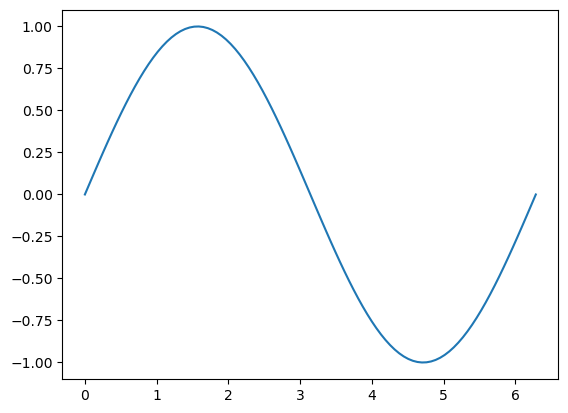

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Create 100 evenly spaced x-values from 0-100
x = np.linspace(0, 2 * np.pi, 100)

# Calculate the sin of each given x-values
y = np.sin(x)

# Create a figure with axes
# Making our drawing space our blank canvas
fig, ax = plt.subplots()

# Creating our "moving" sin wave plot
# One line, not multiple
line, = ax.plot(x, np.sin(x))

def update(frame):
    """
    updating my sin wave by shifting it horizontally
    frame(integer) = current frame number, increasing with time
    line, = (tuple) = the updated line object (being redrawn)
    """
    line.set_ydata(np.sin(x + 2 * frame / 5.0))
    return line,

ani = animation.FuncAnimation(fig, update, frames = 100, interval = 50, blit = True)
plt.show

In [5]:
# ok so i have no idea how to highlight things in python 
# but i changed the frame part and put a 2 * to double the amount of frames per second which should make it twice as fast

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [6]:
#save it as a gif
ani.save("animation1.gif", writer = "pillow", fps = 20)

Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [7]:
# in blit=true, only parts are redrawn, specifically the parts that change, but in blit=false it redraws the whole thing every single time

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

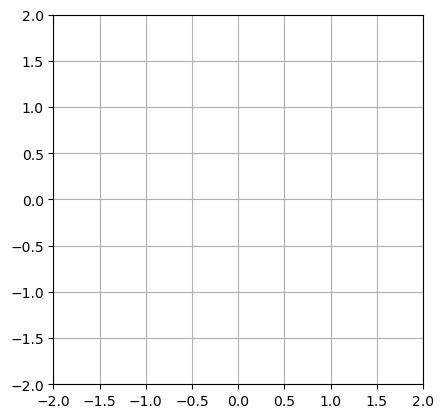

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Create a figure and axis
fig, ax = plt.subplots()
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')  # Keep the circle round
ax.grid()

# Create a point (dot) that will move in a circle
dot, = ax.plot([], [], 'ro', markersize=8)  # 'ro' = red dot

def init():
    """Initialize the dot at the origin (won't be visible initially)."""
    dot.set_data([], [])
    return dot,

def update(frame):
    """Update the dot's position to move in a circular path."""
    theta = 2 * np.pi * frame / 100  # Convert frame to angle (0 to 2π)
    x = np.cos(theta)  # X position
    y = np.sin(theta)  # Y position
    dot.set_data(x, y)
    return dot,

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=100, init_func=init, interval=50, blit=True)

# Show the animation
plt.show()

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [9]:
# Save as a GIF
ani.save("circle_animation.gif", writer="pillow", fps=20)

C:\Users\mmaga\AppData\Local\Temp\ipykernel_9156\134623639.py:25: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  dot.set_data(x, y)


## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [10]:
# Define constants
G = 6.67430e-11  # Gravitational constant

# Masses (kg)
Ms = 1.9885e30    # Mass of the Sun
Me = 5.972e24     # Mass of the Earth
Mm = 6.417e23     # Mass of Mars
Mc = 6.39e20      # Mass of the comet

# Distance and time units
AU = 1.495978707e11  # Astronomical unit
daysec = 86400       # Seconds in a day

# Initial positions
# The Sun = origin
sun_pos = (0, 0, 0)

Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [11]:
e_ap_v = (0, 29290, 0)        # Earth's velocity at aphelion (m/s)
m_ap_v = (0, 22000, 0)         # Mars's velocity at aphelion (m/s)
comet_v = (0, 7000, 0)

Run the cell below to define some gravitational constants because we expect no mass loss:

In [12]:
# Compute gravitational constants
gravconst_e = G * Me
gravconst_m = G * Mm
gravconst_c = G * Mc

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [13]:
# Initial positions
xe, ye, ze = 1.0167 * AU, 0, 0
xm, ym, zm = 1.666 * AU, 0, 0
xc, yc, zc = 2 * AU, 0.3 * AU, 0
xs, ys, zs = 0, 0, 0

We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [14]:
# Initial velocities
xve, yve, zve = 0, e_ap_v, 0
xvm, yvm, zvm = 0, 22000, 0
xvc, yvc, zvc = 0, 7000, 0

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [15]:
# Initial positions
xe, ye, ze = 1.0167 * AU, 0, 0
xm, ym, zm = 1.666 * AU, 0, 0
xc, yc, zc = 2 * AU, 0.3 * AU, 0
xs, ys, zs = 0, 0, 0  # Sun's position at the origin

# Initial velocities
e_ap_v = (0, 29290, 0)  # Earth's velocity at aphelion
m_ap_v = (0, 22000, 0)  # Mars's velocity at aphelion
comet_v = (0, 7000, 0)  # Comet's velocity

xve, yve, zve = 0, e_ap_v[1], 0
xvm, yvm, zvm = 0, m_ap_v[1], 0
xvc, yvc, zvc = 0, comet_v[1], 0
xvs, yvs, zvs = 0, 0, 0  # Sun's velocity

Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [16]:
t = 0  # Initial time
daysec = 86400  # Number of seconds in a day
dt = 1 * daysec  # Time step (steps per day)
years = 5  # Number of years
sim_years = years * 365 * daysec  

Create empty lists to store all of your varibles. Run the cell below.

In [17]:
# Create empty lists to store variables
xelist = []
yelist = []
xmlist = []
ymlist = []
xclist = []
yclist = []
xslist = []
yslist = []

## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [18]:
# Your code here
################ Earth #############
rx, ry, rz = xe - xs, ye - ys, ze - zs
modr3_e = (rx**2 + ry**2 + rz**2)**1.5
fx_e = -gravconst_e * rx / modr3_e
fy_e = -gravconst_e * ry / modr3_e
    
xve += fx_e * dt / Me
yve += fy_e * dt / Me
xe += xve * dt
ye += yve * dt
    
xelist.append(xe)
yelist.append(ye)

################ Mars ##############
rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
fx_m = -gravconst_m * rx_m / modr3_m
fy_m = -gravconst_m * ry_m / modr3_m
    
xvm += fx_m * dt / Mm
yvm += fy_m * dt / Mm
xm += xvm * dt
ym += yvm * dt
    
xmlist.append(xm)
ymlist.append(ym)

################ Comet ##############
rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
fx_c = -gravconst_c * rx_c / modr3_c
fy_c = -gravconst_c * ry_c / modr3_c
    
xvc += fx_c * dt / Mc
yvc += fy_c * dt / Mc
xc += xvc * dt
yc += yvc * dt
    
xclist.append(xc)
yclist.append(yc)

################ Sun ##############
xvs += -(fx_e + fx_m) * dt / Ms
yvs += -(fy_e + fy_m) * dt / Ms
xs += xvs * dt
ys += yvs * dt
xslist.append(xs)
yslist.append(ys)

t += dt

## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

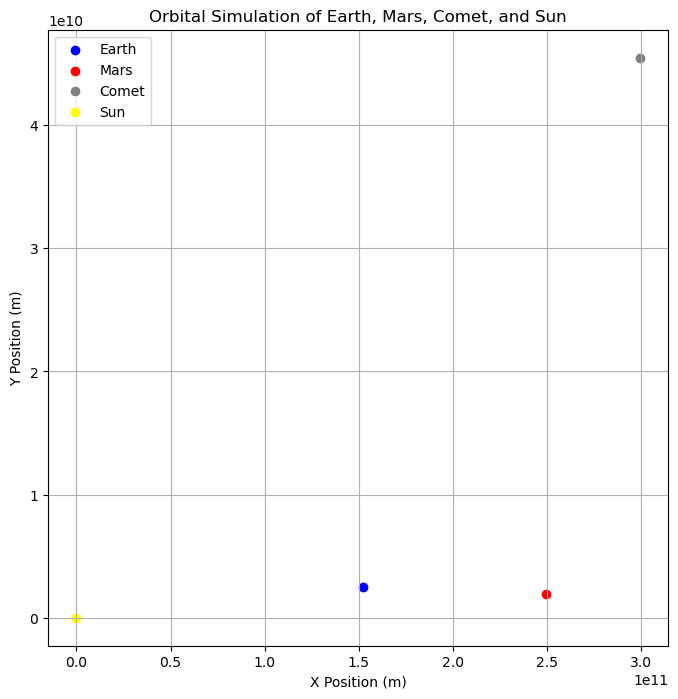

In [20]:
# Create plot
plt.figure(figsize=(8, 8))
plt.scatter(xelist, yelist, label="Earth", color="blue")
plt.scatter(xmlist, ymlist, label="Mars", color="red")
plt.scatter(xclist, yclist, label="Comet", color="grey")
plt.scatter(xslist, yslist, label="Sun", color="yellow")

# Labels and title
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Orbital Simulation of Earth, Mars, Comet, and Sun")

# Show legend and grid
plt.legend()
plt.grid(True)

# Display plot
plt.show()

Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

C:\Users\mmaga\anaconda3\Lib\site-packages\matplotlib\animation.py:1741: UserWarning: Can not start iterating the frames for the initial draw. This can be caused by passing in a 0 length sequence for *frames*.

If you passed *frames* as a generator it may be exhausted due to a previous display or save.
  warnings.warn(


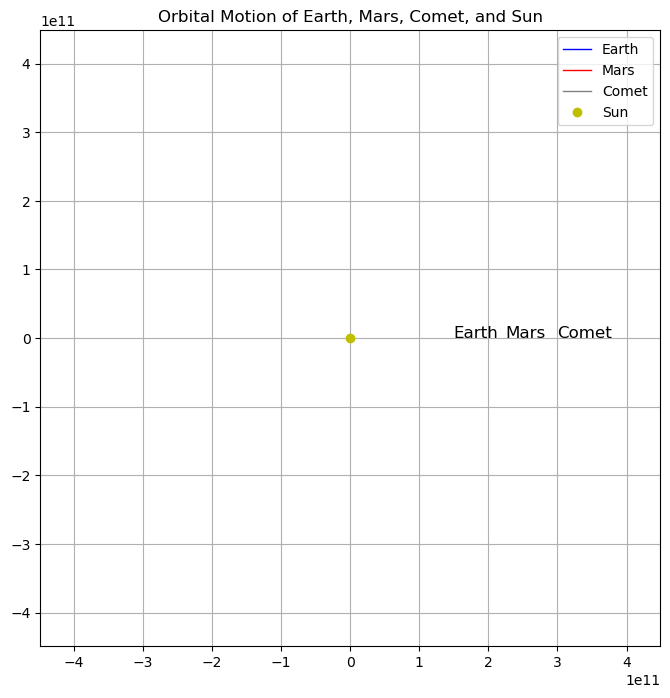

In [22]:
# Initialize empty lists for positions
xelist, yelist = [], []
xmlist, ymlist = [], []
xclist, yclist = [], []
xslist, yslist = [0], [0]  # Sun remains at the origin

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)

# Unpack lines for Earth, Mars, and Comet
line_e, = ax.plot([], [], '-b', lw=1, label="Earth")
line_m, = ax.plot([], [], '-r', lw=1, label="Mars")
line_c, = ax.plot([], [], 'grey', lw=1, label="Comet")

# Unpack points for Earth, Mars, Comet, and Sun
point_e, = ax.plot([], [], 'bo', markersize=4)
point_m, = ax.plot([], [], 'ro', markersize=4)
point_c, = ax.plot([], [], 'ko', markersize=4)
point_s, = ax.plot(0, 0, 'yo', markersize=6, label="Sun")  # Sun at (0,0)

# Add text labels
text_e = ax.text(AU, 0, 'Earth', fontsize=12)
text_m = ax.text(1.5 * AU, 0, 'Mars', fontsize=12)
text_c = ax.text(2 * AU, 0, 'Comet', fontsize=12)

# Update function for animation
def update(i):
    # Update line traces
    line_e.set_data(xelist[:i], yelist[:i])
    line_m.set_data(xmlist[:i], ymlist[:i])
    line_c.set_data(xclist[:i], yclist[:i])

    # Update position markers
    if i < len(xelist):
        point_e.set_data(xelist[i], yelist[i])
        text_e.set_position((xelist[i], yelist[i]))

    if i < len(xmlist):
        point_m.set_data(xmlist[i], ymlist[i])
        text_m.set_position((xmlist[i], ymlist[i]))

    if i < len(xclist):
        point_c.set_data(xclist[i], yclist[i])
        text_c.set_position((xclist[i], yclist[i]))

    return line_e, line_m, line_c, point_e, point_m, point_c, text_e, text_m, text_c

# Create animation
anim = animation.FuncAnimation(fig, update, frames=len(xelist), interval=1, blit=True)

plt.legend()
plt.grid(True)
plt.title("Orbital Motion of Earth, Mars, Comet, and Sun")
plt.show()

## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

C:\Users\mmaga\AppData\Local\Temp\ipykernel_9156\2077568575.py:51: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_e.set_data(xelist[i], yelist[i])


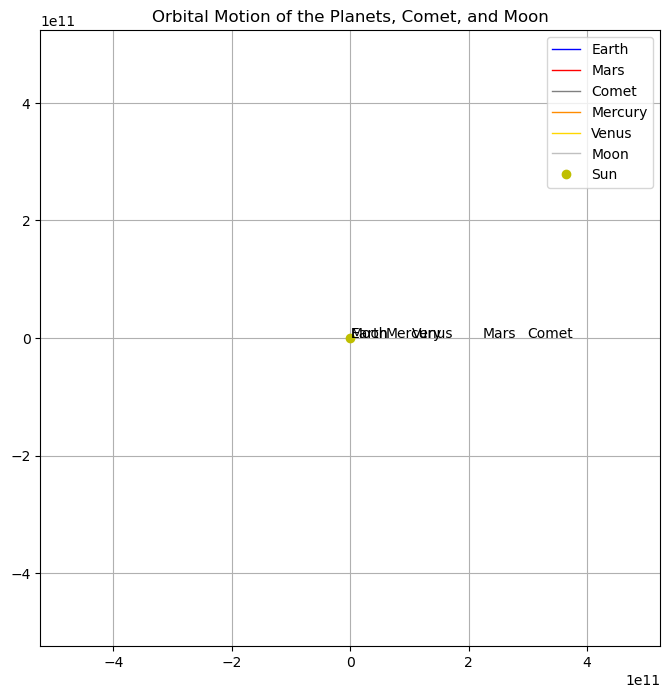

In [28]:
xelist = [i * 1e10 for i in range(100)]  # Simulated x-coordinates
yelist = [i * 1e10 for i in range(100)]  # Simulated y-coordinates

# New celestial bodies
xmerclist, ymerclist = [], []  # Mercury
xvenlist, yvenlist = [], []  # Venus
xmoonlist, ymoonlist = [], []  # Moon

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-3.5 * AU, 3.5 * AU)
ax.set_ylim(-3.5 * AU, 3.5 * AU)

# Unpack lines for planets and Moon
line_e, = ax.plot([], [], '-b', lw=1, label="Earth")
line_m, = ax.plot([], [], '-r', lw=1, label="Mars")
line_c, = ax.plot([], [], color="grey", linestyle="-", lw=1, label="Comet")
line_merc, = ax.plot([], [], color="darkorange", linestyle="-", lw=1, label="Mercury")
line_ven, = ax.plot([], [], color="gold", linestyle="-", lw=1, label="Venus")
line_moon, = ax.plot([], [], color="silver", linestyle="-", lw=1, label="Moon")

# Unpack points for each celestial body
point_e, = ax.plot([], [], 'bo', markersize=4)
point_m, = ax.plot([], [], 'ro', markersize=4)
point_c, = ax.plot([], [], 'ko', markersize=4)
point_merc, = ax.plot([], [], 'o', color="darkorange", markersize=3)
point_ven, = ax.plot([], [], 'o', color="gold", markersize=3)
point_moon, = ax.plot([], [], 'o', color="silver", markersize=2)
point_s, = ax.plot(0, 0, 'yo', markersize=6, label="Sun")  # Sun at (0,0)

# Add text labels
text_e = ax.text(AU, 0, 'Earth', fontsize=10)
text_m = ax.text(1.5 * AU, 0, 'Mars', fontsize=10)
text_c = ax.text(2 * AU, 0, 'Comet', fontsize=10)
text_merc = ax.text(0.4 * AU, 0, 'Mercury', fontsize=10)
text_ven = ax.text(0.7 * AU, 0, 'Venus', fontsize=10)
text_moon = ax.text(0.00257 * AU, 0, 'Moon', fontsize=10)

# Update function for animation
def update(i):
    # Update line traces
    line_e.set_data(xelist[:i], yelist[:i])
    line_m.set_data(xmlist[:i], ymlist[:i])
    line_c.set_data(xclist[:i], yclist[:i])
    line_merc.set_data(xmerclist[:i], ymerclist[:i])
    line_ven.set_data(xvenlist[:i], yvenlist[:i])
    line_moon.set_data(xmoonlist[:i], ymoonlist[:i])

    # Update position markers
    if i < len(xelist):
        point_e.set_data(xelist[i], yelist[i])
        text_e.set_position((xelist[i], yelist[i]))

    if i < len(xmlist):
        point_m.set_data(xmlist[i], ymlist[i])
        text_m.set_position((xmlist[i], ymlist[i]))

    if i < len(xclist):
        point_c.set_data(xclist[i], yclist[i])
        text_c.set_position((xclist[i], yclist[i]))

    if i < len(xmerclist):
        point_merc.set_data(xmerclist[i], ymerclist[i])
        text_merc.set_position((xmerclist[i], ymerclist[i]))

    if i < len(xvenlist):
        point_ven.set_data(xvenlist[i], yvenlist[i])
        text_ven.set_position((xvenlist[i], yvenlist[i]))

    if i < len(xmoonlist):
        point_moon.set_data(xmoonlist[i], ymoonlist[i])
        text_moon.set_position((xmoonlist[i], ymoonlist[i]))

    return (line_e, line_m, line_c, line_merc, line_ven, line_moon, 
            point_e, point_m, point_c, point_merc, point_ven, point_moon, 
            text_e, text_m, text_c, text_merc, text_ven, text_moon)

# Create animation
anim = animation.FuncAnimation(fig, update, frames=len(xelist) if xelist else 1, interval=1, blit=True)


plt.legend()
plt.grid(True)
plt.title("Orbital Motion of the Planets, Comet, and Moon")
plt.show()

Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [29]:
# Your code here
anim.save("animation.gif", writer="pillow", fps=20)

C:\Users\mmaga\AppData\Local\Temp\ipykernel_9156\2077568575.py:51: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_e.set_data(xelist[i], yelist[i])


Upload this notebook and your animations to Gradescope!